# Homework 6 - QP2: Quantum Teleportation

In this assignment, you will form the 'secret' single qubit state $|\Psi\rangle$ on $q_0$, teleport it to another 
qubit $q_2$, and verify that you indeed have the state $|\Psi\rangle$ on $q_2$ from the measured histogram. Form 
your own unique 'secret' state $|\Psi\rangle$. You may use any number of single qubit gates ($\mathrm{X}$, $\mathrm{Y}$, $\mathrm{Z}$, $\mathrm{H}$, $\mathrm{S}$, $\mathrm{T}$), in any combination or order, or use any Rotation gate $\mathrm{R_x(\theta)}, \mathrm{R_y(\theta)} or \mathrm{R_z(\theta)}$ for any angle of rotation $\theta$.

Instead of Alice conducting measurements on her two qubits $q_0$ & $q_1$ and classically communicating her findings to Bob who has the qubit $q_2$, in this assignment we will replace this action by the controlled operations where $q_0$ and $q_1$ act as the contorls (Alice) and $q_2$ as the target (Bob).

Since this assignment is the first time you will create a multi qubit circuit and use a multi qubit 
gate, I will give below a qiskit code that prepares a 'secret' state $|\Psi\rangle = \mathrm{R_y(-2\pi/5)}|0\rangle$ on $q_0$, and then the entangled Bell state $|\beta_{00}\rangle$ on $q_1 q_2$. The three qubits state is $|\Psi\rangle |\beta_{00}\rangle$. You should write the rest.

Measure the output state of $q_2$ and verify that it agrees with the state $|\Psi\rangle$ you prepared on $q_0$.

Do both the *simulation* and the IBM *real system computation*.

<u>Report</u>: a single PDF file (Total 70 pts).

## 1. The quantum circuit (Total 40 pts):

(A) explain each program line about what it does (10 pts). 

(B) The completed circuit image output (5 pts). 

(C) Explain how the following **(1) & (2) are equivalent**:
- (1) Alice measuring her 2 qubits $q_0$ & $q_1$ and informing Bob her results and Bob doing the single qubit operation *conditioned* by Alice's measurement result.
- (2) Performing controlled operations from $q_0$ (control) to $q_2$ (target), and from $q_1$ (control) to $q_2$ (target) (15 pts).

(D) Handwrite the three qubit states $|q_0 q_1 q_2\rangle$ at each time step on the circuit (10 pts).

## 2. Simulation:

The simulation output and explain if the histogram is **consistent** with your 'secret' state $|\Psi\rangle$ (15 pts).

## 3. IBM real system result:

The histogram and discuss if it is **consistent** with your 'secret' state $|\Psi\rangle$ (15 pts).

For any number of the common single qubit gates ($\mathrm{X}$, $\mathrm{Y}$, $\mathrm{Z}$, $\mathrm{H}$, $\mathrm{S}$, $\mathrm{T}$) and the Rotation gate with some particular rotation angles, you can analytically write $|\Psi\rangle$. If your state $|\Psi\rangle$ an not be written analytically because you used a Rotation gate with an angle that does not give you the Sin or Cos values in a closed form, then you should write a separate code to simulate and measure the qubit $q_0$ right after you have prepared $|\Psi\rangle$ with a Rotation gate. Then you will know what result $|\Psi\rangle$ to expect after the *teleportation*.

<u>Note</u>: beginneing of the code

```Python
import numpy as np
from qiskit import QuantumCircuit, transpile
nqua=3 
circuit=QuantumCircuit(nqua,1) # circuit with 3 qubits and 1 classical bit. 
circuit.ry(-2.0*np.pi/5.0,0)   #prepare q0 in cos(p/5)|0>+i sin(p/5)|1> 
circuit.h(1)  #q1 = uniform superposition state 
circuit.cx(1,2) #q1=control, q2=target. It produces the Bell state |b00> on q1q2. 
circuit.barrier()  # separator in circuit drawing to force gates to line up. 
circuit.draw(output='mpl', style='iqp')  #draw the circuit 
```

![fig1](/Users/yuyaohuang/Github/EE520_QC_and_device/HW6/QP-2_fig1.png)


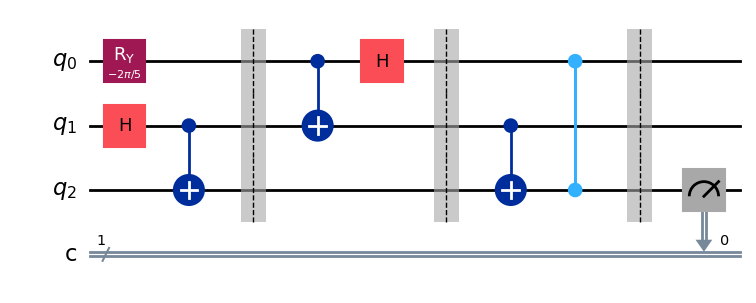

In [7]:
"""Problem 1 - Quantum Teleportation Circuit"""

import numpy as np
from qiskit import QuantumCircuit, transpile

# ── Build the 3-qubit teleportation circuit ──────────────────────────────────
nqua = 3
circuit = QuantumCircuit(nqua, 1)  # 3 qubits, 1 classical bit for measuring q2

# (A) Line-by-line explanation:
# Step 1: Prepare the 'secret' state |ψ⟩ on q0
#   Ry(-2π/5) rotates q0 by -2π/5 around the Y-axis:
#   |ψ⟩ = cos(π/5)|0⟩ − sin(π/5)|1⟩  ≈  0.809|0⟩ − 0.588|1⟩
circuit.ry(-2.0*np.pi/5.0, 0)   # prepare q0 in |ψ⟩ = cos(π/5)|0⟩ − sin(π/5)|1⟩

# Step 2: Create the Bell state |β₀₀⟩ = (|00⟩+|11⟩)/√2 on q1 and q2
#   First put q1 into an equal superposition with a Hadamard gate
circuit.h(1)                     # q1 → (|0⟩+|1⟩)/√2
#   Then entangle q1 and q2 with a CNOT (q1=control, q2=target)
#   Together these two gates produce the Bell pair shared between Alice (q1) and Bob (q2)
circuit.cx(1, 2)                 # CNOT(q1→q2): produces |β₀₀⟩ on q1q2

circuit.barrier()                # visual separator: preparation | teleportation

# Step 3: Alice's Bell-basis rotation on her two qubits q0 & q1
#   This is the unitary equivalent of projecting onto the Bell basis
#   (replaces Alice's measurement + classical communication via the deferred measurement principle)
circuit.cx(0, 1)                 # CNOT(q0→q1): entangle secret qubit with Alice's Bell qubit
circuit.h(0)                     # H(q0): complete the Bell-basis change on q0

circuit.barrier()                # visual separator: Alice's side | Bob's correction

# Step 4: Bob's conditional corrections on q2 (controlled by q0 and q1)
#   These controlled gates replace "Bob applies X/Z depending on Alice's classical message"
circuit.cx(1, 2)                 # CNOT(q1→q2): applies X to q2 when q1=|1⟩  (X correction)
circuit.cz(0, 2)                 # CZ(q0→q2):  applies Z to q2 when q0=|1⟩  (Z correction)

circuit.barrier()                # visual separator: corrections | measurement

# Step 5: Measure q2 to verify teleportation
#   After the corrections q2 should be in state |ψ⟩; measure it into classical bit 0
circuit.measure(2, 0)            # measure q2 → classical bit 0

# (B) Draw the completed circuit
circuit.draw(output='mpl', style='iqp')


Simulation counts (shots=8192): {'1': 2811, '0': 5381}
P(0) measured = 0.6569  (theory: cos²(π/5) = 0.6545)
P(1) measured = 0.3431  (theory: sin²(π/5) = 0.3455)


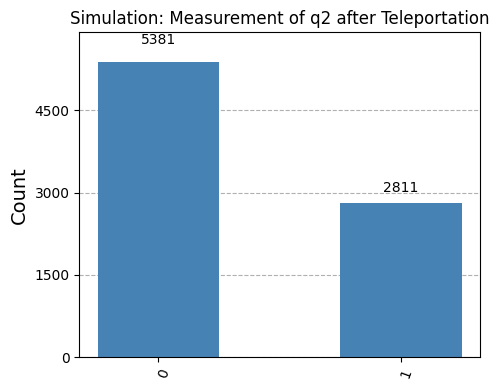

In [8]:
"""Problem 2 - Simulation"""

import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# ── Rebuild the teleportation circuit (same as Problem 1) ────────────────────
nqua = 3
circuit = QuantumCircuit(nqua, 1)

circuit.ry(-2.0*np.pi/5.0, 0)  # secret state |ψ⟩ = cos(π/5)|0⟩ − sin(π/5)|1⟩ on q0
circuit.h(1)                    # Hadamard on q1
circuit.cx(1, 2)                # CNOT(q1→q2): Bell state |β₀₀⟩ on q1q2
circuit.barrier()

circuit.cx(0, 1)                # CNOT(q0→q1): Alice's Bell-basis rotation step 1
circuit.h(0)                    # H(q0): Alice's Bell-basis rotation step 2
circuit.barrier()

circuit.cx(1, 2)                # CNOT(q1→q2): X correction on q2
circuit.cz(0, 2)                # CZ(q0→q2):   Z correction on q2
circuit.barrier()

circuit.measure(2, 0)           # measure q2 → classical bit 0

# ── Run simulation with AerSimulator ─────────────────────────────────────────
simulator = AerSimulator()
shots = 8192
compiled = transpile(circuit, simulator)
job = simulator.run(compiled, shots=shots)
result = job.result()
counts = result.get_counts()

print(f"Simulation counts (shots={shots}):", counts)
print(f"P(0) measured = {counts.get('0', 0)/shots:.4f}  (theory: cos²(π/5) = {np.cos(np.pi/5)**2:.4f})")
print(f"P(1) measured = {counts.get('1', 0)/shots:.4f}  (theory: sin²(π/5) = {np.sin(np.pi/5)**2:.4f})")

# ── Plot histogram ────────────────────────────────────────────────────────────
plot_histogram(counts, title="Simulation: Measurement of q2 after Teleportation",
               color='steelblue', figsize=(5, 4))


qiskit_runtime_service._discover_account:WARNING:2026-04-09 20:20:46,209: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-04-09 20:20:49,362: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-04-09 20:20:49,957: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-09 20:20:51,894: Using instance: open-instance, plan: open


Using backend: ibm_fez
Circuit depth after transpilation: 28
Job ID: d7c44pb0g7hs73dqa920  (status: QUEUED)
Waiting for job to complete...

Real system counts (shots=8192): {'0': 5202, '1': 2990}
P(0) measured = 0.6350  (theory: cos²(π/5) = 0.6545)
P(1) measured = 0.3650  (theory: sin²(π/5) = 0.3455)


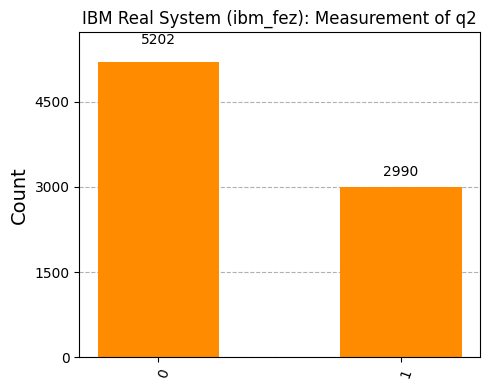

In [9]:
"""Problem 3 - IBM Real System"""

import json
import numpy as np
from pathlib import Path
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ── Load API key from file (do NOT hardcode keys in notebooks) ───────────────
key_path = Path(__file__).parent.parent / "apikey.json" if "__file__" in dir() else Path("../apikey.json")
with open(key_path) as f:
    api_key = json.load(f)["apikey"]

# ── Connect to IBM Quantum and pick the least-busy backend ──────────────────
service = QiskitRuntimeService(channel="ibm_quantum_platform", token=api_key)
backend = service.least_busy(operational=True, simulator=False, min_num_qubits=3)
print(f"Using backend: {backend.name}")

# ── Build the teleportation circuit (same as Problems 1 & 2) ────────────────
nqua = 3
circuit = QuantumCircuit(nqua, 1)

circuit.ry(-2.0*np.pi/5.0, 0)  # secret state |ψ⟩ = cos(π/5)|0⟩ − sin(π/5)|1⟩ on q0
circuit.h(1)                    # Hadamard on q1
circuit.cx(1, 2)                # CNOT(q1→q2): Bell state |β₀₀⟩ on q1q2
circuit.barrier()

circuit.cx(0, 1)                # CNOT(q0→q1): Alice's Bell-basis rotation step 1
circuit.h(0)                    # H(q0): Alice's Bell-basis rotation step 2
circuit.barrier()

circuit.cx(1, 2)                # CNOT(q1→q2): X correction on q2
circuit.cz(0, 2)                # CZ(q0→q2):   Z correction on q2
circuit.barrier()

circuit.measure(2, 0)           # measure q2 → classical bit 0
# ── Transpile using backend.target to avoid plugin compatibility issues ──────
# ── Transpile for the selected backend ──────────────────────────────────────
pm = generate_preset_pass_manager(target=backend.target, optimization_level=1)
compiled = pm.run(circuit)
print(f"Circuit depth after transpilation: {compiled.depth()}")

# ── Run on the real system using SamplerV2 ───────────────────────────────────
sampler = Sampler(mode=backend)
job = sampler.run([compiled], shots=shots)
print(f"Job ID: {job.job_id()}  (status: {job.status()})")
print("Waiting for job to complete...")

# ── Retrieve and display results ─────────────────────────────────────────────
result = job.result()
pub_result = result[0]
counts = pub_result.data.c.get_counts()   # classical register 'c' (bit 0)

print(f"\nReal system counts (shots={shots}):", counts)
print(f"P(0) measured = {counts.get('0', 0)/shots:.4f}  (theory: cos²(π/5) = {np.cos(np.pi/5)**2:.4f})")
print(f"P(1) measured = {counts.get('1', 0)/shots:.4f}  (theory: sin²(π/5) = {np.sin(np.pi/5)**2:.4f})")

plot_histogram(counts, title=f"IBM Real System ({backend.name}): Measurement of q2",
               color='darkorange', figsize=(5, 4))

